# CLUSTERING ANALYSIS 

### Understanding and Implementing K-Means, Hierarchical, and DBSCAN Algorithms

### Objective:

In [1]:
## • The objective of this assignment is to introduce to various clustering algorithms, including K-Means, hierarchical, and DBSCAN, and provide hands-on experience in applying these techniques to a real-world dataset.

### Datasets :

In [2]:
## • East-West Airlines is trying to learn more about its customers. Key issues are their flying patterns, earning and use of frequent flyer rewards, and use of the airline credit card. The task is to identify customer segments via clustering.

## • Source: Based upon real business data; company names have been changed. (c) 2016 Galit Shmueli and Peter Bruce


## Field Name	    	  Raw Data or Telcom Created Field?	                              Description
## ID#	                       		  Telcom	                                           Unique ID
## Balance	                           Raw	                             Number of miles eligible for award travel
## Qual_miles	                       Raw	                             Number of miles counted as qualifying for Topflight status
## cc1_miles	                   	   Raw	                     Number of miles earned with freq. flyer credit card in the past 12 months:
## cc2_miles                           Raw	                        Number of miles earned with Rewards credit card in the past 12 months:
## cc3_miles	                       Raw	                    Number of miles earned with Small Business credit card in the past 12 months:
##                                                                      note:  miles bins:				1 = under 5,000
##				                                                                                        2 = 5,000 - 10,000
##   			                                                                                        3 = 10,001 - 25,000
##				                                                                                        4 = 25,001 - 50,000
##				                                                                                        5 = over 50,000
## Bonus_miles	                	   Raw	                     Number of miles earned from non-flight bonus transactions in the past 12 months
## Bonus_trans			               Raw	                       Number of non-flight bonus transactions in the past 12 months
## Flight_miles_12mo	       		   Raw	                              Number of flight miles in the past 12 months
## Flight_trans_12	            	   Raw 	                        Number of flight transactions in the past 12 months
## Days_since_enroll           	      Telcom	                                 Number of days since Enroll_date
## Award?	                    	  Telcom	                        Dummy variable for Last_award (1=not null, 0=null)

In [3]:
import pandas as pd
import numpy as np

### Data Preprocessing:

In [4]:
## • 1.	Preprocess the dataset to handle missing values, remove outliers, and scale the features if necessary.
## • 2.	Perform exploratory data analysis (EDA) to gain insights into the distribution of data and identify potential clusters.
## • 3.	Use multiple visualizations to understand the hidden patterns in the dataset

In [5]:
## Load the dataset and view top 2 records..
df = pd.read_excel("EastWestAirlines.xlsx")
df.head(2)

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [7]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [8]:
## The dataset contains 3999 observations and 12 numerical features. There are no missing values in the dataset.. 
## All the variables are numeric in nature. The column ID# represents a unique ID and does not contribute to clustering process..
## So ID# will be dropped before model building.. 

df = df.drop("ID#", axis = 1)
df.columns

Index(['Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award?'],
      dtype='object')

In [9]:
## From the summary statistics it can be seen that some variables such as Balance, Bonus_miles and Flight_miles_12mo contain some extreme values..
## It indicates the presence of outliers.. these values may affect the clustering performance..
## we will have to handel them appropriately as required..
## At the same time we need keep this in mind that in clustering we do not agrresively removes outliers, instead we can try scaling and get good results..
## Also scaling is important here because some columns have values in lakhs and some have values between (1-5).. we need to bring them in similar scale..
## Since there are no null values present in the given dataset  and all the column has numeric datatype so we can directly jump to scalling part..

In [10]:
## Scaling.. 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [11]:
print(scaled_data)

[[-4.51140783e-01 -1.86298687e-01 -7.69578406e-01 ... -3.62167870e-01
   1.39545434e+00 -7.66919299e-01]
 [-5.39456874e-01 -1.86298687e-01 -7.69578406e-01 ... -3.62167870e-01
   1.37995704e+00 -7.66919299e-01]
 [-3.20031232e-01 -1.86298687e-01 -7.69578406e-01 ... -3.62167870e-01
   1.41192021e+00 -7.66919299e-01]
 ...
 [-4.29480975e-05 -1.86298687e-01  6.83121167e-01 ... -3.62167870e-01
  -1.31560393e+00  1.30391816e+00]
 [-1.85606976e-01 -1.86298687e-01 -7.69578406e-01 ... -9.85033311e-02
  -1.31608822e+00 -7.66919299e-01]
 [-7.00507951e-01 -1.86298687e-01 -7.69578406e-01 ... -3.62167870e-01
  -1.31754109e+00 -7.66919299e-01]]


In [12]:
## Since clustering algorithm such as K-Means and DBSCAN are distance based algorithm..
## So feature scaling is applied using StandardScaler to ensure that all the variables contribute equally to the clustering process..

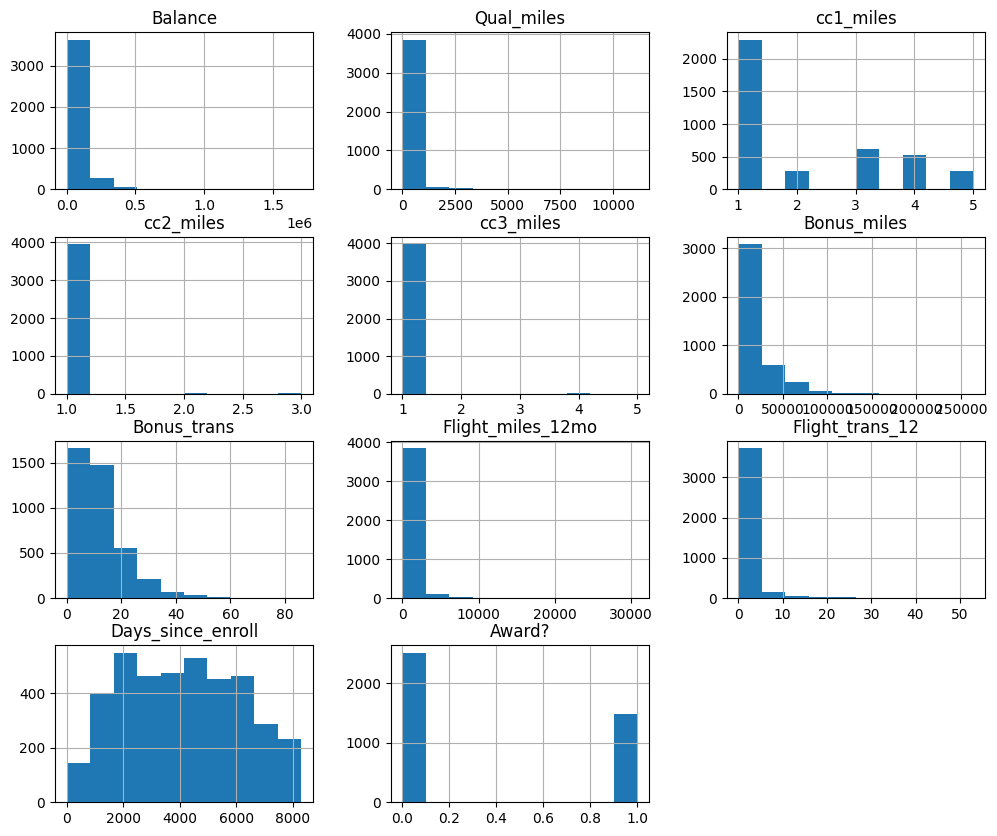

In [13]:
## Distribution plots..
import matplotlib.pyplot as plt
import seaborn as sns

df.hist(figsize = (12, 10))
plt.show()

In [14]:
## The histogram plots shows that most of the variables in the dataset are highly right skewed..
## Meaning that a large number of customers have lower values while only a few customers have very high values..

## The variables Balance, Bonus_miles and Flight_miles_12mo show strong skewness with a few extreme high values..
## This indicates the presence of high value customers who travel frequently or accumulate larger miles..

## The variable cc1_miles,cc2_miles and cc3_miles are discrete in nature  and mostly concetrated in lower categories, 
## indicating that most customers falls into lower mileage categories..

## The Days_since_enroll feature apppears to be more uniformly distributed compared to other variables..
## this suggests that customers have been enrolled over wide range of time periods..

## The Award? variable is binary showing two distinct categories (0, 1) indicating whether a customer received an award or not..

## Overall the dataset shows significant variation in customer behavior with a majority of customers having lower activity levels..
## A small group of highly active customers which suggets the presence of potential clusters..


Column: Balance
Q1 : 18527.5
Q3 : 92404.0
IQR : 73876.5
Lower Bound : -92287.25
Upper Bound : 203218.75
Minimum Value : 0
Maximum Value : 1704838
Potential Outiers : 266


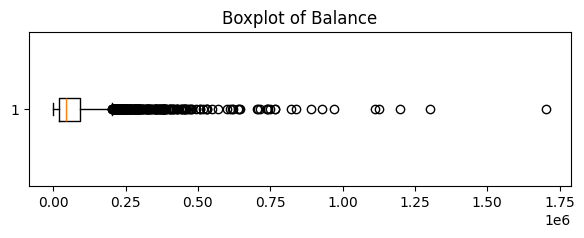

****************************************************************************************************

Column: Qual_miles
Q1 : 0.0
Q3 : 0.0
IQR : 0.0
Lower Bound : 0.0
Upper Bound : 0.0
Minimum Value : 0
Maximum Value : 11148
Potential Outiers : 226


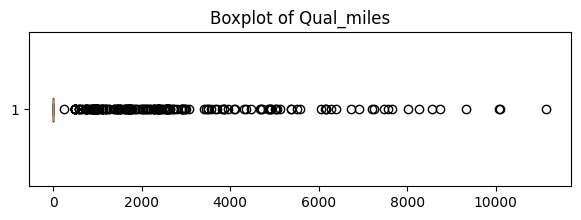

****************************************************************************************************

Column: cc1_miles
Q1 : 1.0
Q3 : 3.0
IQR : 2.0
Lower Bound : -2.0
Upper Bound : 6.0
Minimum Value : 1
Maximum Value : 5
Potential Outiers : 0


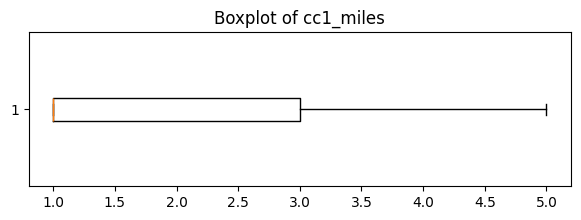

****************************************************************************************************

Column: cc2_miles
Q1 : 1.0
Q3 : 1.0
IQR : 0.0
Lower Bound : 1.0
Upper Bound : 1.0
Minimum Value : 1
Maximum Value : 3
Potential Outiers : 43


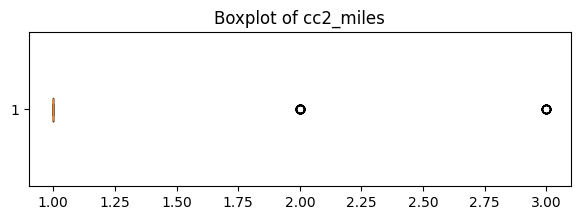

****************************************************************************************************

Column: cc3_miles
Q1 : 1.0
Q3 : 1.0
IQR : 0.0
Lower Bound : 1.0
Upper Bound : 1.0
Minimum Value : 1
Maximum Value : 5
Potential Outiers : 18


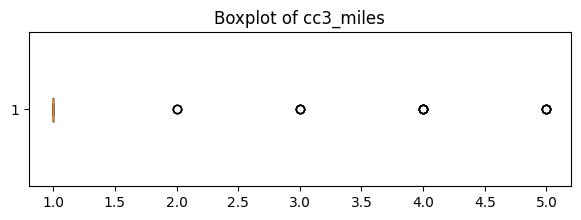

****************************************************************************************************

Column: Bonus_miles
Q1 : 1250.0
Q3 : 23800.5
IQR : 22550.5
Lower Bound : -32575.75
Upper Bound : 57626.25
Minimum Value : 0
Maximum Value : 263685
Potential Outiers : 280


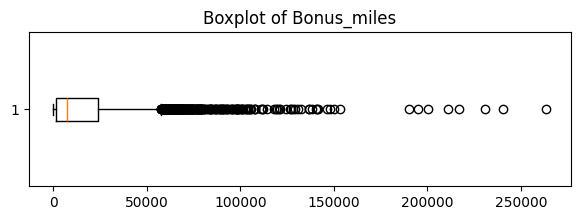

****************************************************************************************************

Column: Bonus_trans
Q1 : 3.0
Q3 : 17.0
IQR : 14.0
Lower Bound : -18.0
Upper Bound : 38.0
Minimum Value : 0
Maximum Value : 86
Potential Outiers : 63


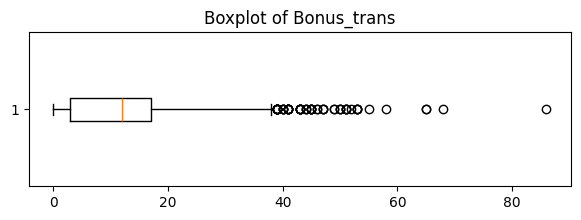

****************************************************************************************************

Column: Flight_miles_12mo
Q1 : 0.0
Q3 : 311.0
IQR : 311.0
Lower Bound : -466.5
Upper Bound : 777.5
Minimum Value : 0
Maximum Value : 30817
Potential Outiers : 569


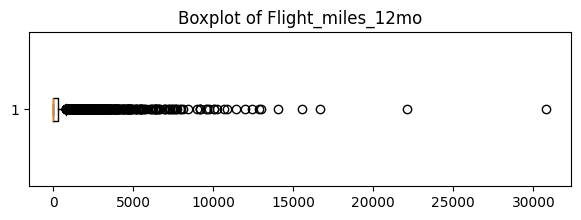

****************************************************************************************************

Column: Flight_trans_12
Q1 : 0.0
Q3 : 1.0
IQR : 1.0
Lower Bound : -1.5
Upper Bound : 2.5
Minimum Value : 0
Maximum Value : 53
Potential Outiers : 565


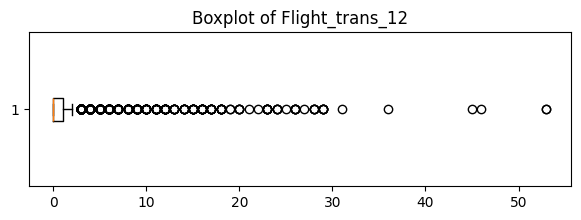

****************************************************************************************************

Column: Days_since_enroll
Q1 : 2330.0
Q3 : 5790.5
IQR : 3460.5
Lower Bound : -2860.75
Upper Bound : 10981.25
Minimum Value : 2
Maximum Value : 8296
Potential Outiers : 0


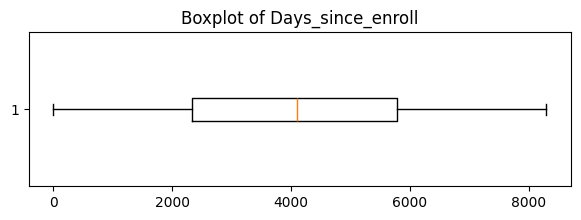

****************************************************************************************************

Column: Award?
Q1 : 0.0
Q3 : 1.0
IQR : 1.0
Lower Bound : -1.5
Upper Bound : 2.5
Minimum Value : 0
Maximum Value : 1
Potential Outiers : 0


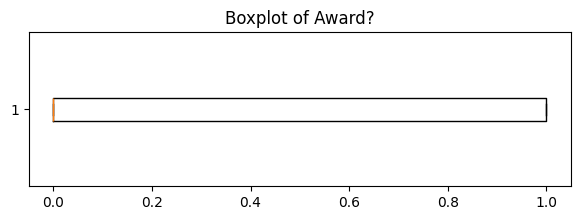

****************************************************************************************************


In [15]:
## Let's plot Box-plot..

for i in df.columns:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    min_val = df[i].min()
    max_val = df[i].max()

    ## detect outliers..
    outliers = df[(df[i] < lower_bound) | (df[i] > upper_bound)][i]

    print(f"\nColumn: {i}")
    print(f"Q1 : {Q1}")
    print(f"Q3 : {Q3}")
    print(f"IQR : {IQR}")
    print(f"Lower Bound : {lower_bound}")
    print(f"Upper Bound : {upper_bound}")
    print(f"Minimum Value : {min_val}")
    print(f"Maximum Value : {max_val}")
    print(f"Potential Outiers : {len(outliers)}")
#    if len(outliers) > 0:
#        print("Potential Outliers:")
#        print(outliers.values)
    
    plt.figure(figsize = (7, 2))
    plt.boxplot(df[i].dropna(), vert = False)
    plt.title(f"Boxplot of {i}")
    plt.show()

    print("*"*100)

In [16]:
## The Boxplots indicates the presence of several potential outliers in feature such as Balance, Qual_miles, cc2_miles, Bonus_miles, Bonus_trans, Flight_miles_12mo and Flight_trans_12..
## These outliers represents customers with unusually high actvity levels which might form seperate clusters..

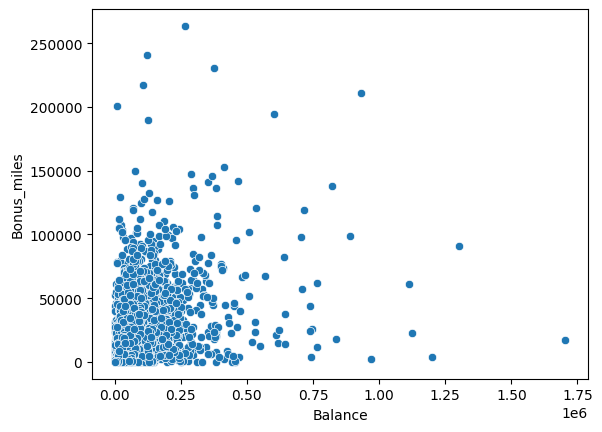

In [17]:
## Scatter plot..
sns.scatterplot(x = "Balance", y = "Bonus_miles", data = df)
plt.show()

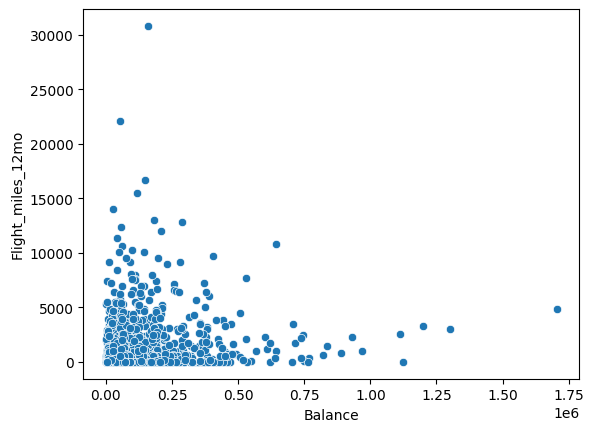

In [18]:
sns.scatterplot(x = "Balance", y = "Flight_miles_12mo", data = df)
plt.show()

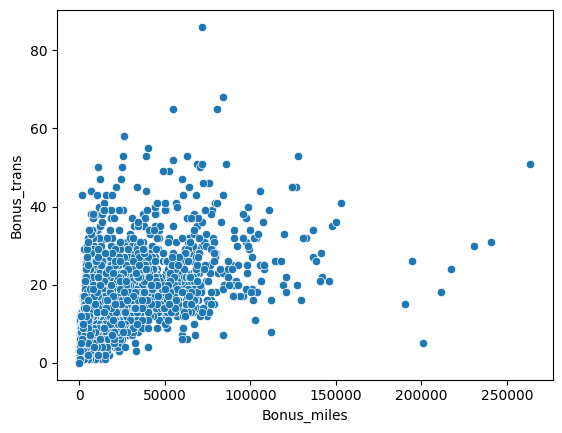

In [19]:
sns.scatterplot(x = "Bonus_miles", y = "Bonus_trans", data = df)
plt.show()

In [20]:
## The Scatter plot show that there is no clear linear pattern between variables but some grouping tendencies can be seen.. 
## Certain customers have high balances and high bonus miles while other have low values, it shows potential clusters..

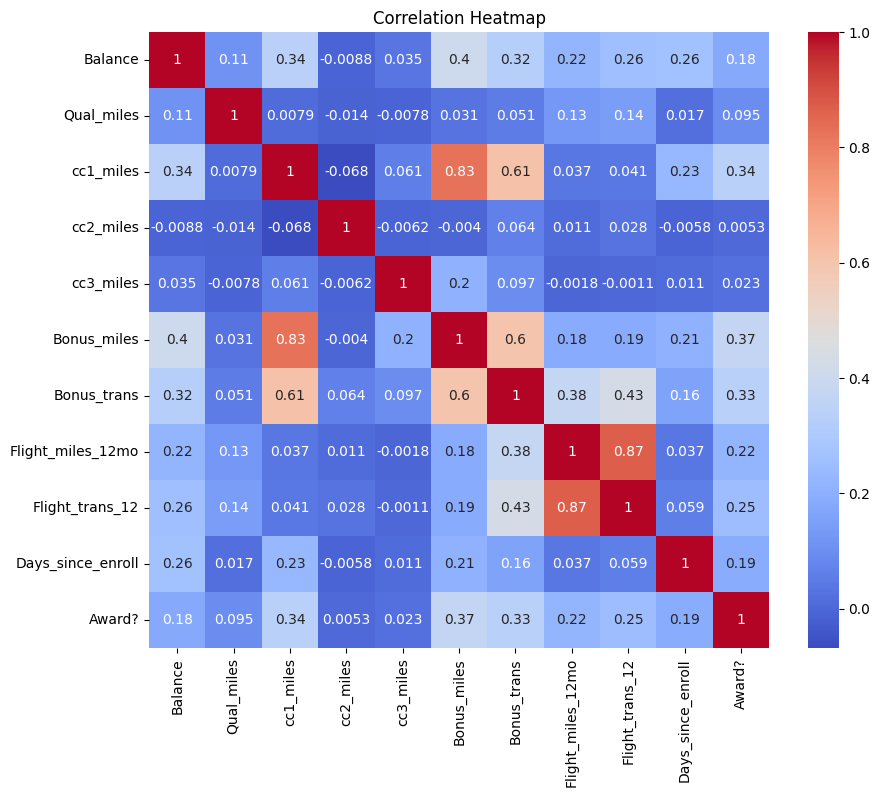

In [21]:
## Correlation Heatmap.. 
plt.figure(figsize = (10, 8))
sns.heatmap(df.corr(), annot = True, cmap = "coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [22]:
## The correlation heatmap shows that most of the variables have low correlation (around 0.3 or less)..
## This shows that features are largely indepenedent and capture different aspects of the customer..

## However few feture pairs show moderate to strong correlations..
## For example, Bonus_miles and cc1_miles (0.83), and Flight_trans_12 and Flight_miles_12mo (0.87) are having strong positive correlation..
## This shows that customers who can earn more also tend to have more transactions in those categories..

## Similarly Bonus_miles and Bonus_trans (0.6) and Bonus_trans and cc1_miles (0.61) show moderate correlation..
## This indicates some level of connection between overall acount balance and reward activity..

## Overall most of the features are weakly correlated, the presence of few strongly correlated variables suggests that certain customer behavior are closely related..
## This information is  useful for clustering as it might influence  how group formed..

### Implementing Clustering Algorithms

In [23]:
## •	Implement the K-Means, hierarchical, and DBSCAN algorithms using a programming language such as Python with libraries like scikit-learn or MATLAB.
## •	Apply each clustering algorithm to the pre-processed dataset to identify clusters within the data.
## •	Experiment with different parameter settings for hierarchical clustering (e.g., linkage criteria), K-means(Elbow curve for different K values) and DBSCAN (e.g., epsilon, minPts) and evaluate the clustering results.

### Cluster Analysis and Interpretation

In [24]:
## •	Analyse the clusters generated by each clustering algorithm and interpret the characteristics of each cluster. Write you insights in few comments.

### Visualization

In [25]:
## • Visualize the clustering results using scatter plots or other suitable visualization techniques.
## • Plot the clusters with different colours to visualize the separation of data points belonging to different clusters.

#### K-Means Clustering..

In [26]:
from sklearn.cluster import KMeans

In [27]:
## Elbow Method.. find optimal K
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, random_state = 42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

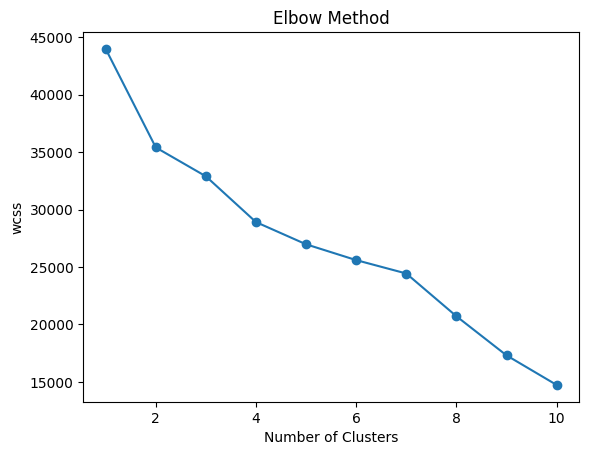

In [28]:
plt.plot(range(1, 11), wcss, marker = "o")
plt.xlabel("Number of Clusters")
plt.ylabel("wcss")
plt.title("Elbow Method")
plt.show()

In [29]:
## The elbow method graph shows a sharp decrease in wcss from k = 1 to k = 4, after which rate of decrease becomes more gradual..
## This indicates that adding more clusters beyonds this point does not significantly reduce the within-cluster sum of squares..
## The elbow point appears around k = 4 suggesting that 4 clusters is an optimal choice for this dataset..
## The graph is not very sharp elbow type, but the best logical bend is at k = 4..
## even though the curve drops again around k = 8, but choosing it wil probably cause overfitting.. 

In [30]:
kmeans = KMeans(n_clusters = 4, random_state = 42)
kmeans_labels = kmeans.fit_predict(scaled_data)

df["KMeans_cluster"] = kmeans_labels

In [31]:
df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_cluster
0,28143,0,1,1,1,174,1,0,0,7000,0,2
1,19244,0,1,1,1,215,2,0,0,6968,0,2
2,41354,0,1,1,1,4123,4,0,0,7034,0,2
3,14776,0,1,1,1,500,1,0,0,6952,0,2
4,97752,0,4,1,1,43300,26,2077,4,6935,1,1


In [32]:
## Cluster profiling..
df.groupby("KMeans_cluster").mean()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
KMeans_cluster,,,,,,,,,,,
0,193291.147436,795.455128,2.179487,1.038462,1.000000,32292.288462,27.628205,5530.230769,16.211538,4688.070513,0.820513
1,122119.899548,151.724887,3.885068,1.002715,1.043439,43772.394570,19.398190,366.520362,1.087783,4777.394570,0.687783
2,59693.586570,112.733010,1.372168,1.031553,1.000809,6311.116505,8.456311,258.830097,0.806634,5744.810680,0.296117
3,36920.458056,96.690413,1.269640,1.006658,1.000000,4897.208389,6.790280,167.861518,0.509321,2236.466711,0.151132


In [33]:
## The KMeans clustering divided the customers into 4 distinct groups based on their behavior and activity levels..

## Cluster 0 (High value customers)
## Customer in this have very high balance, high bonus miles and highest number of flight miles and transactions..
## They also show a high value in the award variable indicating that most of them have received rewards..
## These customers represent high value and frequent flyers who are highly engaged with airline..

## Cluster 1 (High Bonus but low Flight activity)
## In this customers have high bonus miles and relatively high balance, but very low flight miles and transactions..
## This means they earn rewards through non flight activities (like credit cards) rather than actual travel..
## They can be considered reward focused customers with low frequency travels..

## Cluster 2 (Moderate customers)
## Customers in this show moderate balance, moderate bonus miles and low flight activity..
## Their values are neither very high nor very low compared to other clusters..
## They can be considered average or regular customers with moderate engagement..


## Cluster 3 (Low value customers)
## They have the lowest balance, lowest bonus miles and minimal flight transactions..
## They also have the lowest value for the Award variable. 
## These customers represents low engagement or inactive customers..


## The cluster results clearly separate customers into different segments such as high value frequent flyers, reward based users, moderate users and low value users..
## This segmentation can help the airline design targeted marketing stratergies for different customers groups..

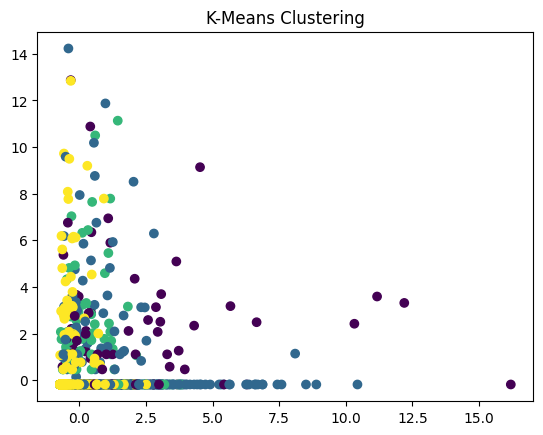

In [34]:
## Visualisation..
plt.scatter(scaled_data[:, 0], scaled_data[:, 1], c = kmeans_labels)
plt.title("K-Means Clustering")
plt.show()

In [35]:
## The scatter plot shows the clustering results obtained from the KMeans algorithm where the different color represents different segments..
## The data points are not  very clearly seperated and there is a significant overlap between clusters..
## This means that the dataset does not have very distinct boundaries between customer groups..
## However some grouping patterns can still be observed..a large number of customers are concentrated in the lower range of values..
## This shows that most customer have lower activity levels..
## A few data points are spread far from the main cluster, representing high value or outlier customers..
## The presence of overlapping clusters indicates that while KMeans has grouped the data, the seperation between clusters is not very strong.. 
## This is common in real world dataset to be honest as far as i researched about them..
## Overall the visualisation shows that KMeans had identified segments but the clusters are not sharply defined indicating moderate clustering performance..

#### Hierarchical clustering

In [36]:
from scipy.cluster.hierarchy import dendrogram, linkage

In [37]:
## Linkage matrix
linkage_methods = ["ward","complete", "average", "single"]

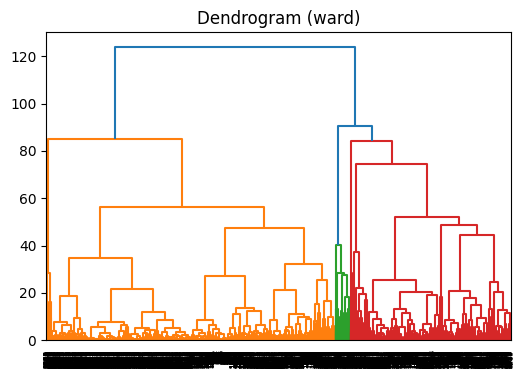

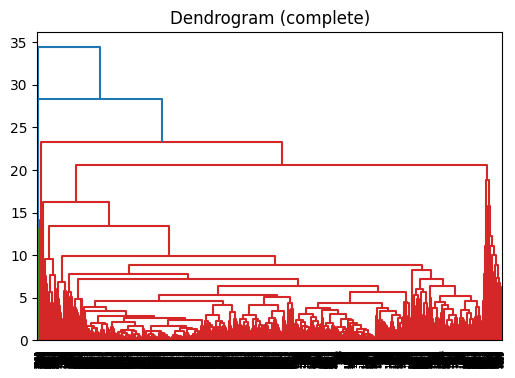

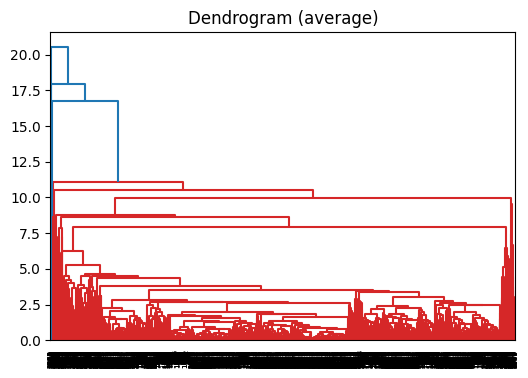

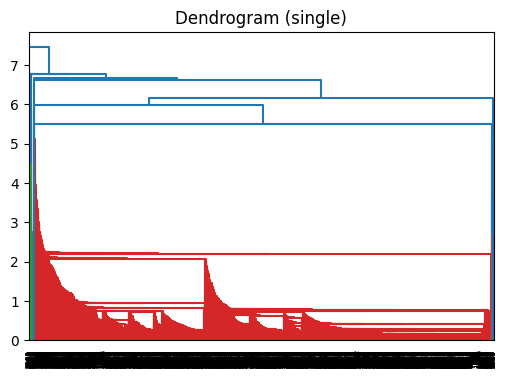

In [38]:
## plot dendrogram
for i in linkage_methods:
    Z = linkage(scaled_data, method = i)
    plt.figure(figsize = (6, 4))
    dendrogram(Z)
    plt.title(f"Dendrogram ({i})")
    plt.show()

In [39]:
## Different linkage methods were tested and ward linkage is the best with clear and better cluster seperation..

In [40]:
## WARD linkage dendrogram (selected)..
## Now we decide on optimal number of clusters..
## From the dendrogram a significant vertical distance is observed at higher levels in ward linkage..
## This indicates strong seperation between cluster at that point..
## By cutting the dendrogram at an appropriate distance (around 70-80), 4 clusters are identified as the optimal number..
## This choice balances cluster seperation and interpretability.. 

In [41]:
## Agglomerative clustering 
from sklearn.cluster import AgglomerativeClustering

hierarchical_c = AgglomerativeClustering(n_clusters = 4, linkage = "ward")
hierarchical_c_labels = hierarchical_c.fit_predict(scaled_data)

In [42]:
## Add this to data frame as well.. 
df["HC_cluster"] = hierarchical_c_labels

In [43]:
df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_cluster,HC_cluster
0,28143,0,1,1,1,174,1,0,0,7000,0,2,1
1,19244,0,1,1,1,215,2,0,0,6968,0,2,1
2,41354,0,1,1,1,4123,4,0,0,7034,0,2,1
3,14776,0,1,1,1,500,1,0,0,6952,0,2,1
4,97752,0,4,1,1,43300,26,2077,4,6935,1,1,0


In [44]:
## Cluster profiling 
df.groupby("HC_cluster").mean()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_cluster
HC_cluster,,,,,,,,,,,,
0,116314.450725,363.839130,3.498551,1.000000,1.035507,37150.356522,18.066667,377.000000,1.150000,4696.888406,0.663043,1.255797
1,46329.336877,9.028618,1.244072,1.000000,1.000000,4868.112428,6.907604,214.812756,0.673753,3769.337694,0.184383,2.552330
2,134880.892308,393.323077,2.430769,1.000000,1.000000,36582.169231,29.338462,5915.523077,16.638462,4599.607692,0.753846,0.176923
3,68876.581395,23.255814,1.139535,2.348837,1.000000,14689.837209,17.534884,582.627907,2.209302,3968.930233,0.395349,1.953488


In [45]:
## Cluster 2: High value customers segment..
## This cluster got highest Balance, very high Bonus miles and Bonus transactions, Highest Flight miles and Flight transcations...'
## High Award rate.. these are frequent and premium customers..Highly engaged with airlines services.. and actively use rewards and benifits..

## Cluster 0: Moderate loyality, High value customer..
## High balance, Good Bonus miles, moderate Transations, Low flight activity in comparison with cluster 2, Good Award rate..
## Customers are loyal but less frequent flyers, Likely use credit card benifts more than flights

## Cluster 3: Moderate customers..
## Medium Balance, moderate Bonus miles, low flight activity, moderate Award rate..
## Average customers with moderate engagement, not highly active in flight or rewards..

## Cluster 1: Low value customers..least valuable segment..
## Lowest Balance, very low Bonus miles, minimal Flight activity, very low Award rate..
## Inactive or low engagement customers, rarely use airline services or rewards..

## Hierarchical clustering successfully segmented customers into 4 distinct groups ranging from high value frequent flyers to low activity customers..
## The results are consistent with K-Means clustering, indicating stble and meaningful customer segementation..

## The clustering shows that variable like Bonus miles, Flight activity and Balance play a key role in differenciating customer segments..

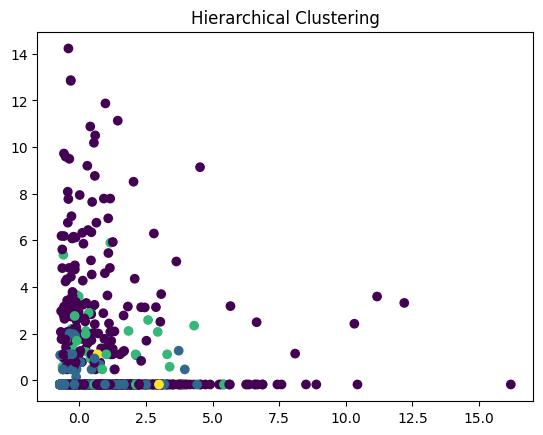

In [46]:
## Visualization for Hierarchical clustering..
plt.scatter(scaled_data[:, 0], scaled_data[:, 1], c = hierarchical_c_labels)
plt.title("Hierarchical Clustering")
plt.show()

In [47]:
## The scatter plot show that most data points are concentrated in the dense region at lower feature values forming the primary clusters..

## A few clusters are distinguishable with moderate seperation while some overlap is still present..
## indicating that the dataset does not have very clearly defined boundaries..

## Additionally some data points are spread far from the main cluster groups representing potential outliers..

## Overall it provides relatively better seperation compared to K-Means but some overlap still exists..

#### DBSCAN 

In [48]:
## Group data based on density, can detect outliers (noice points), and no need to specify number of clusters..

In [49]:
## import
from sklearn.cluster import DBSCAN

In [50]:
## applying DBSCAN
dbscan = DBSCAN(eps = 1.5, min_samples = 5)
db_labels = dbscan.fit_predict(scaled_data)

In [51]:
## Add this to dataframe..
df["DBSCAN_cluster"] = db_labels

In [52]:
df.columns

Index(['Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award?', 'KMeans_cluster', 'HC_cluster',
       'DBSCAN_cluster'],
      dtype='object')

In [53]:
df["DBSCAN_cluster"].value_counts()

## (-1) basically represents outliers here.. 
## A significant number of data points are labeled as -1..
## DBSCAN is effectively identifying outliers in the dataset.. these customers behave very differently from normal patterns..
## This is an advantage over K-Means and Hierarchical clustering..
## Cluster 0 and 1 have large number of data points.. 2,3 and 4 have very few observations..
## It means DBSCAN is forming few dense clusters.. smaller cluster represent rare customer segments..

DBSCAN_cluster
 0    2411
 1    1250
-1     310
 2      15
 3       8
 4       5
Name: count, dtype: int64

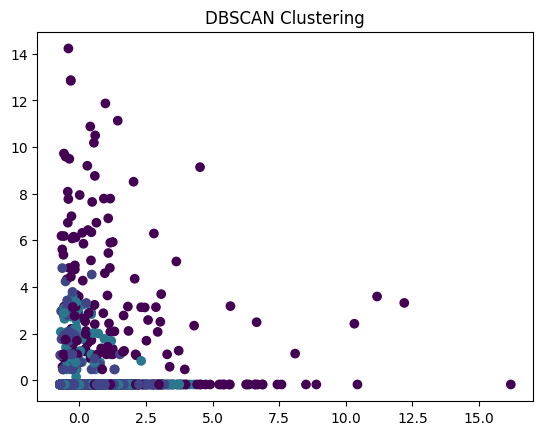

In [54]:
## Visualization for DBSCAN
plt.scatter(scaled_data[:, 0], scaled_data[:, 1], c = db_labels)
plt.title("DBSCAN Clustering")
plt.show()

In [55]:
## Most points are densely packed near origin, some scatter points are far away (outliers)..
## Clusters are not clearly seperable..
## DBSCAN struggels to form clean clusters due to uneven density, presence of significant amount of outliers..

In [56]:
## Compared to K-Means and Hierarchical, DBSCAN detects outliers but poor cluster seperation here..
## K-Means has better structured clusters
## In case of Hierarchical, clear grouping is there via dendrogram..

In [57]:
## Lets try Tuning Eps for better performance of DBSCAN
eps = [0.5, 0.8, 1.0, 2.0]
for i in eps:
    dbscan = DBSCAN(eps = i, min_samples = 5)
    labels = dbscan.fit_predict(scaled_data)

    print("Eps", i)
    print("Clusters", len(set(labels)) - (1 if -1 in labels else 0))
    print("Noise points", list(labels).count(-1))
    print("-"*30)

Eps 0.5
Clusters 16
Noise points 1413
------------------------------
Eps 0.8
Clusters 8
Noise points 776
------------------------------
Eps 1.0
Clusters 6
Noise points 554
------------------------------
Eps 2.0
Clusters 6
Noise points 179
------------------------------


In [58]:
## it can be seen that at lower eps values the number of noice points is very high..indicating overly strict clustering..
## We will choose eps = 1.0, because it has balanced number of clusters, acceptable noice..
## Not too strict not too loose..

## Why not eps = 2? because it has very low noice, same cluster as eps = 1.0.. too relaxed, might merge different clusters.. 
## Risk of loosing meaningful insights..

In [59]:
dbscan = DBSCAN(eps = 1.0, min_samples = 5)
db_labels_final = dbscan.fit_predict(scaled_data)

In [60]:
df["DBSCAN_cluster_final"] = db_labels_final

In [61]:
## Cluster profiling for DBSCAN 
df.groupby("DBSCAN_cluster_final").mean()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_cluster,HC_cluster,DBSCAN_cluster
DBSCAN_cluster_final,,,,,,,,,,,,,,
-1,184010.198556,947.731047,2.754513,1.059567,1.088448,40265.904332,22.375451,2194.700361,6.324910,4757.777978,0.691336,1.079422,0.687726,-0.231047
0,53298.132385,4.695558,1.658042,1.000000,1.000000,9046.818025,8.468305,133.003881,0.422165,3799.103924,0.000000,2.404053,0.854248,0.000000
1,61334.918573,9.830741,2.591034,1.000000,1.000000,22886.188472,12.860018,286.425435,0.912168,4503.006404,1.000000,1.671546,0.380604,1.000000
2,34806.538462,0.000000,1.000000,2.000000,1.000000,8389.769231,12.000000,19.230769,0.153846,3186.153846,0.000000,2.538462,3.000000,2.000000
3,38616.166667,0.000000,1.000000,3.000000,1.000000,14966.833333,14.000000,41.666667,0.166667,3835.666667,0.000000,2.000000,3.000000,3.000000
4,164883.400000,1471.600000,1.000000,1.000000,1.000000,8472.800000,5.000000,300.000000,1.400000,4173.400000,1.000000,2.200000,0.000000,1.000000
5,27113.888889,2475.444444,1.000000,1.000000,1.000000,2169.111111,4.555556,44.444444,0.333333,1900.111111,0.000000,3.000000,0.000000,0.000000


In [62]:
## DBSCAN identified multiple clusters along with one noice cluster (-1), which contain significant number of data points..
## The noice cluster represents customer with very high values in features like Balance, Bonus miles, and Flight activity..
## This indicates that these are outliers..

## Some clusters like 0 and 2,consists of customers with low Balance, low Flight miles and fewer Transactions.. 
## This represents low engagements or inactive customers..

## Cluster 1 shows relatively moderate activity, with average values across most feature.. indicating medium engagement customers..

## Smaller clusters like (3, 4 and 5), represent those with slightly higher Bonus miles, or specific card usage patterns or limited travel patterns..

## Overall DBSCAN successfully seperates High value outliers and low and medium engagement customers groups..

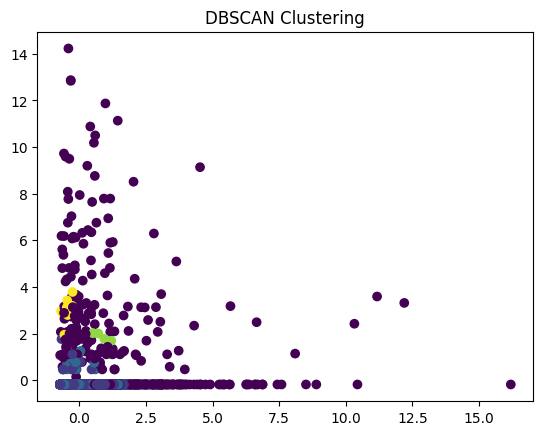

In [63]:
## Visualization for DBSCAN (eps = 1)
plt.scatter(scaled_data[:, 0], scaled_data[:, 1], c = db_labels_final)
plt.title("DBSCAN Clustering")
plt.show()

In [64]:
## The scatter plot shows that most data points are densely concentrated near the lower range of feature values, forming main clusters..

## A large number of points are marked as noise (outliers), which are spread across the plot, especially in higher value regions..
## This indicates the presence of customer with unusual or extreme behaviour..

## The cluster that are not very well seperated and show overlap, suggesting that the datasethas varying density and no clear boundaries between groups..

## Compared to other clustering methods DBSCAN effectively identifies outliers and dense region but does not produce very clearly seperated clusters..

## Overall the visualization confirms that DBSCAN is suitable for detecting irregular patterns and outliers, even though cluster seperation is moderate..

### Evaluation and Performance Metrics

In [65]:
## • Evaluate the quality of clustering using internal evaluation metrics such as silhouette score for K-Means and DBSCAN.

#### Silhoutte Score

In [66]:
from sklearn.metrics import silhouette_score

In [67]:
## KMeans
sil_kmeans = silhouette_score(scaled_data, kmeans_labels)

## Hierarchical
sil_hc = silhouette_score(scaled_data, hierarchical_c_labels)

## DBSCAN (ignore noice points = -1)
sil_dbscan = silhouette_score(scaled_data[db_labels_final != -1], db_labels_final[db_labels_final != -1])

print("KMeans Silhouette Score:", sil_kmeans)
print("Hierarchical Silhouette Score:", sil_hc)
print("DBSCAN Silhouette Score:", sil_dbscan)

KMeans Silhouette Score: 0.19071186813310886
Hierarchical Silhouette Score: 0.30814152852022786
DBSCAN Silhouette Score: 0.281707334271592


In [68]:
## The Silhouette score is used to evaluate the quality of clustering where values closer to 1 indicates well seperated clusters..
## The values closer to 0 indicates overlapping clusters..

## K-Means achieved a Silhouette score of 0.19 indicating relatively weak cluster seperation and higher overlap between clusters..

## Hierarchical clustering achieved a Silhouette score of 0.31 which is the highest among the three methods indicating better defined and more distinct clusters..

## DBSCAN achieved a Silhouette score of 0.28 (after removing noice points)..it shows moderate cluster quality and reasonable seperation..

## Based on these results Hierarchical clustering performs better in terms of cluster seperation.. 

In [69]:
## Final conclusion..

## All three clustering algorithm were applied and evaluated on the dataset..

## K-Means produced clusters but showed weaker seperation (least Silhouette Score)..

## Hierarchical clustering provided the best performance with highest Silhouette Score and meaningful cluster structure..
## hence making it the most suitable method for this dataset..

## DBSCAN was effective in identifying noice points and outliers which is an advantage over other methods
## but the cluster seperation was slightly lower than Hierarchical clustering..

## Overall, Hierarchical clustering is the best performing algorithm for this dataset..
## DBSCAN is useful for detecting outliers,,